Status: All 7 Regional and Tiered CSVs have been generated successfully.

--- MASTER COMPARISON TABLE ---
          Segment  Orders  Avg Time  Traffic Jam Penalty  Peak Hour  \
0  Cleaned_Global   40215     26.26                 9.85         21   
1     North_India   13162     26.42                 9.99         17   
2     South_India   14668     26.25                 9.91         21   
3     North_Urban    2939     23.17                 8.63         22   
4     North_Metro    9851     27.42                 9.78         19   
5     South_Urban    3214     22.73                 8.24         22   
6     South_Metro   10978     27.29                 9.79         21   

   Vehicle Cond.  Fog Frequency %  
0           1.00            17.02  
1           1.01            17.15  
2           1.00            16.94  
3           1.06            15.35  
4           1.00            17.83  
5           1.08            14.97  
6           0.98            17.50  


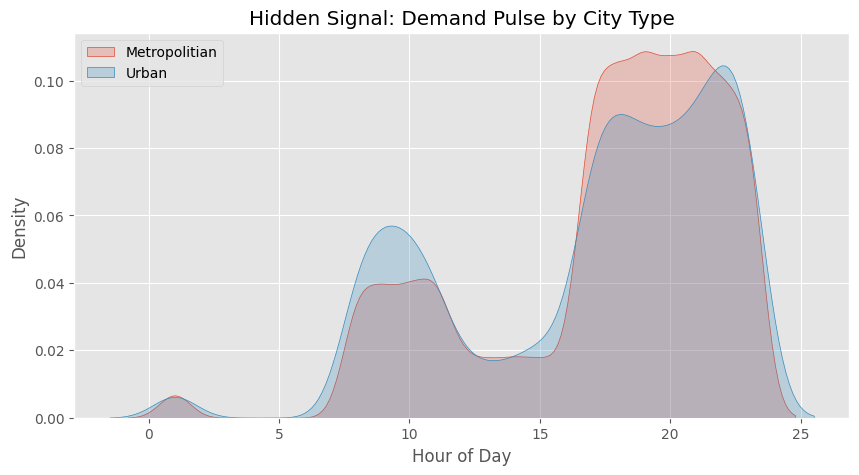

C:\Users\sur3s\AppData\Local\Temp\ipykernel_12096\2374946492.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Avg Time', data=comparison_df, palette='coolwarm')


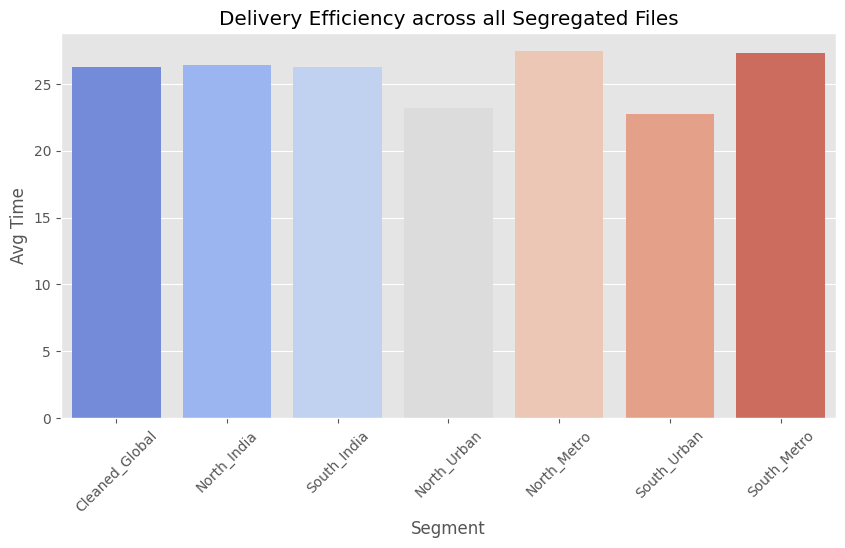

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- STEP 1: SETUP & DATA INGESTION ---
plt.style.use('ggplot')
df = pd.read_csv('Zomato_Delivery_Cleaned.csv')

# --- STEP 2: FEATURE ENGINEERING (Hidden Signals) ---
# 1. Regional Mapping (North vs South)
df['City_Code'] = df['Delivery_person_ID'].str[:3]
north_codes = ['JAP', 'AGR', 'LUD', 'KNP', 'ALH', 'DEH', 'IND', 'BHP', 'RAN', 'KOL']
south_codes = ['BAN', 'HYD', 'MYS', 'COI', 'CHE', 'KOC']

def map_region(code):
    if code in north_codes: return 'North India'
    if code in south_codes: return 'South India'
    return 'West/Other'

df['Region'] = df['City_Code'].apply(map_region)

# 2. Temporal Mapping (Peak Hour Extraction)
def extract_hour(time_str):
    try:
        return int(str(time_str).split(':')[0])
    except:
        return np.nan

df['Order_Hour'] = df['Time_Orderd'].apply(extract_hour)
df = df.dropna(subset=['Order_Hour']) # Removing 'Noise'
df['Order_Hour'] = df['Order_Hour'].astype(int)

# --- STEP 3: SEGMENTATION (Creating the 7 Files) ---
# Saving Regional Files
df[df['Region'] == 'North India'].to_csv('Zomato_North_India.csv', index=False)
df[df['Region'] == 'South India'].to_csv('Zomato_South_India.csv', index=False)

# Saving Tiered Files (Urban vs Metro)
segments = {
    "North_Urban": df[(df['Region'] == 'North India') & (df['City'] == 'Urban')],
    "North_Metro": df[(df['Region'] == 'North India') & (df['City'] == 'Metropolitian')],
    "South_Urban": df[(df['Region'] == 'South India') & (df['City'] == 'Urban')],
    "South_Metro": df[(df['Region'] == 'South India') & (df['City'] == 'Metropolitian')]
}

for name, data in segments.items():
    data.to_csv(f'Zomato_{name}.csv', index=False)

print("Status: All 7 Regional and Tiered CSVs have been generated successfully.")

# --- STEP 4: MASTER COLUMN DIFFERENCE AUDIT ---
file_summary = []
all_files = {
    "Cleaned_Global": df,
    "North_India": df[df['Region'] == 'North India'],
    "South_India": df[df['Region'] == 'South India'],
    **segments
}

for label, data in all_files.items():
    jam_delay = data[data['Road_traffic_density'] == 'Jam']['Time_taken (min)'].mean() - \
                data[data['Road_traffic_density'] == 'Low']['Time_taken (min)'].mean()
    
    file_summary.append({
        'Segment': label,
        'Orders': len(data),
        'Avg Time': round(data['Time_taken (min)'].mean(), 2),
        'Traffic Jam Penalty': round(jam_delay, 2),
        'Peak Hour': data['Order_Hour'].mode()[0],
        'Vehicle Cond.': round(data['Vehicle_condition'].mean(), 2),
        'Fog Frequency %': round((data['Weather_conditions'] == 'Fog').mean() * 100, 2)
    })

comparison_df = pd.DataFrame(file_summary)
print("\n--- MASTER COMPARISON TABLE ---")
print(comparison_df)

# --- STEP 5: VISUALIZATIONS ---
# 1. Peak Hour Demand Signal
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df['City'] == 'Metropolitian'], x='Order_Hour', label='Metropolitian', fill=True)
sns.kdeplot(data=df[df['City'] == 'Urban'], x='Order_Hour', label='Urban', fill=True)
plt.title('Hidden Signal: Demand Pulse by City Type')
plt.xlabel('Hour of Day')
plt.legend()
plt.show()

# 2. Efficiency Comparison
plt.figure(figsize=(10, 5))
sns.barplot(x='Segment', y='Avg Time', data=comparison_df, palette='coolwarm')
plt.title('Delivery Efficiency across all Segregated Files')
plt.xticks(rotation=45)
plt.show()

Status: Feature Engineering Complete.
File Generated: Zomato_Global_Cleaned.csv | Rows: 40215
File Generated: Zomato_North_India.csv | Rows: 13162
File Generated: Zomato_South_India.csv | Rows: 14668
File Generated: Zomato_North_Metro.csv | Rows: 9851
File Generated: Zomato_North_Urban.csv | Rows: 2939
File Generated: Zomato_South_Metro.csv | Rows: 10978
File Generated: Zomato_South_Urban.csv | Rows: 3214

MASTER LOGISTICS & QUALITY AUDIT
       Segment  Orders  Avg Time (min)  Traffic Delay (min)  Peak Hour  Avg Rating  Vehicle Cond.  Multi-Deliveries  Fog Risk %  Storm Risk %
Global_Cleaned   40215           26.26                 9.85         21        4.64           1.00              0.74       17.02         16.92
   North_India   13162           26.42                 9.99         17        4.63           1.01              0.75       17.15         16.79
   South_India   14668           26.25                 9.91         21        4.63           1.00              0.74       16.94    

C:\Users\sur3s\AppData\Local\Temp\ipykernel_12096\2947302511.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Avg Time (min)', data=comparison_df, palette='magma')


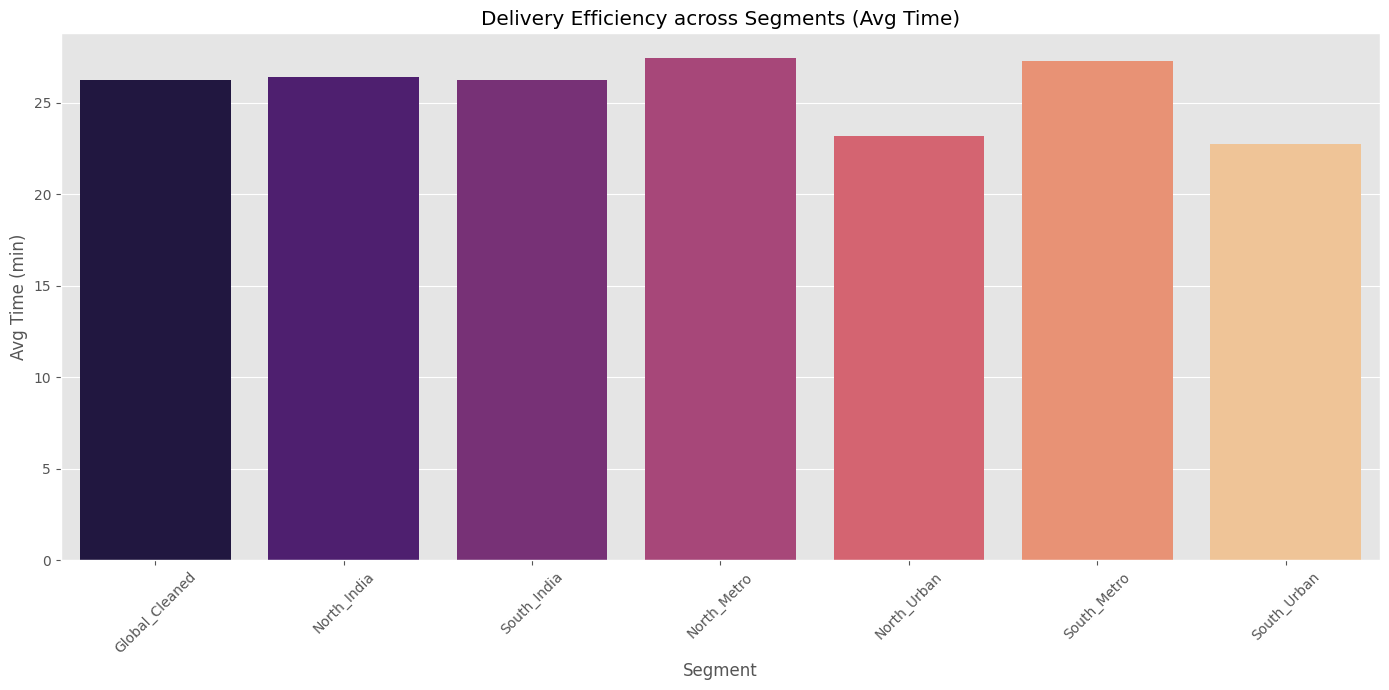

C:\Users\sur3s\AppData\Local\Temp\ipykernel_12096\2947302511.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Avg Rating', data=comparison_df, palette='YlGnBu')


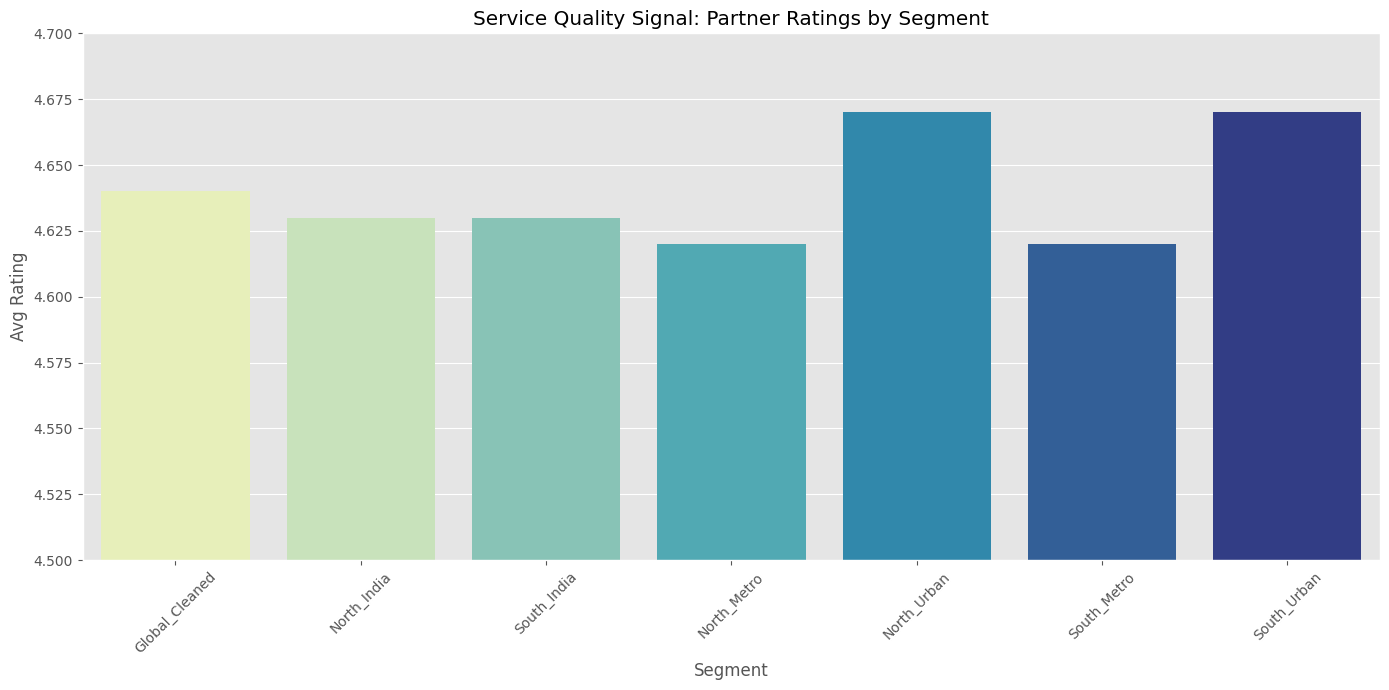

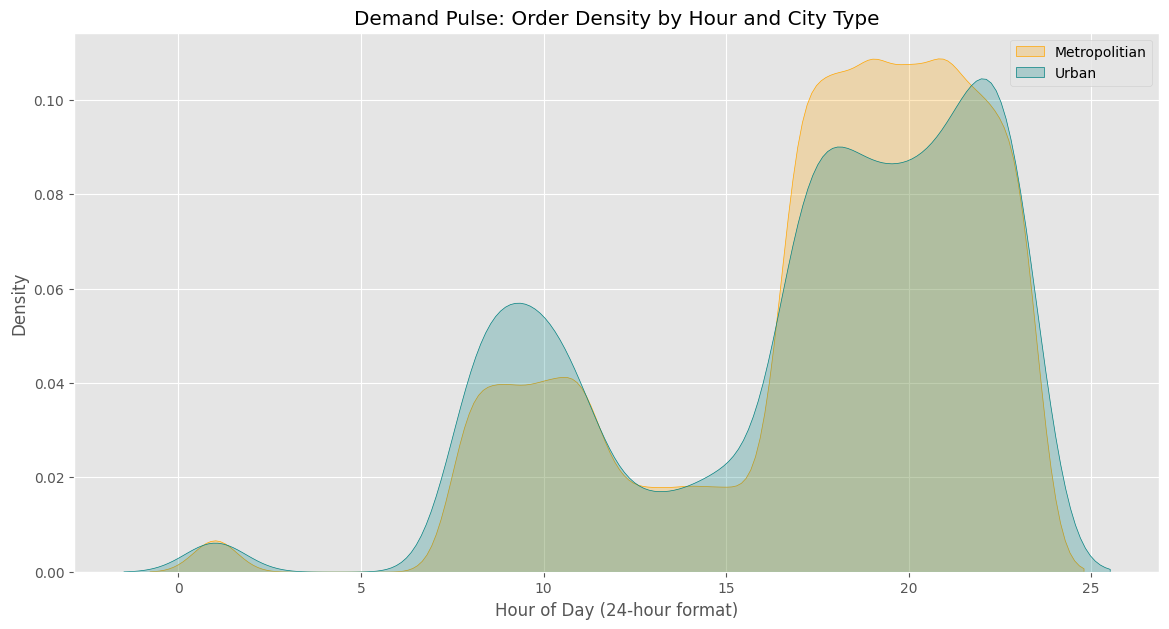

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- STEP 1: GLOBAL CONFIGURATION ---
plt.style.use('ggplot')
sns.set_palette("viridis")

# Load your pre-cleaned dataset
# Ensure Zomato_Delivery_Cleaned.csv is in your working directory
df = pd.read_csv('Zomato_Delivery_Cleaned.csv')

# --- STEP 2: ADVANCED FEATURE ENGINEERING (Creating Signals) ---

# 1. Engineering the 'Region' Feature
df['City_Code'] = df['Delivery_person_ID'].str[:3]
north_codes = ['JAP', 'AGR', 'LUD', 'KNP', 'ALH', 'DEH', 'IND', 'BHP', 'RAN', 'KOL']
south_codes = ['BAN', 'HYD', 'MYS', 'COI', 'CHE', 'KOC']

def map_region(code):
    if code in north_codes: return 'North India'
    if code in south_codes: return 'South India'
    return 'West/Other'

df['Region'] = df['City_Code'].apply(map_region)

# 2. Engineering the 'Order_Hour' Feature
def extract_hour(time_str):
    try:
        return int(str(time_str).split(':')[0])
    except:
        return np.nan

df['Order_Hour'] = df['Time_Orderd'].apply(extract_hour)
df = df.dropna(subset=['Order_Hour']) # Removing noise in time data
df['Order_Hour'] = df['Order_Hour'].astype(int)

print("Status: Feature Engineering Complete.")

# --- STEP 3: SEGMENTATION & DATA STORAGE ---

# Defining our 7 target segments
segments = {
    "Global_Cleaned": df,
    "North_India": df[df['Region'] == 'North India'],
    "South_India": df[df['Region'] == 'South India'],
    "North_Metro": df[(df['Region'] == 'North India') & (df['City'] == 'Metropolitian')],
    "North_Urban": df[(df['Region'] == 'North India') & (df['City'] == 'Urban')],
    "South_Metro": df[(df['Region'] == 'South India') & (df['City'] == 'Metropolitian')],
    "South_Urban": df[(df['Region'] == 'South India') & (df['City'] == 'Urban')]
}

# Saving all 7 files for the 3:00 PM Pivot
for name, data in segments.items():
    data.to_csv(f'Zomato_{name}.csv', index=False)
    print(f"File Generated: Zomato_{name}.csv | Rows: {len(data)}")

# --- STEP 4: MASTER LOGISTICS COMPARISON AUDIT ---

audit_results = []

for name, data in segments.items():
    # Calculate Traffic Delay Signal (Jam vs Low)
    try:
        jam_avg = data[data['Road_traffic_density'] == 'Jam']['Time_taken (min)'].mean()
        low_avg = data[data['Road_traffic_density'] == 'Low']['Time_taken (min)'].mean()
        traffic_delay = jam_avg - low_avg
    except:
        traffic_delay = np.nan
        
    audit_results.append({
        'Segment': name,
        'Orders': len(data),
        'Avg Time (min)': round(data['Time_taken (min)'].mean(), 2),
        'Traffic Delay (min)': round(traffic_delay, 2),
        'Peak Hour': data['Order_Hour'].mode()[0],
        'Avg Rating': round(data['Delivery_person_Ratings'].mean(), 2),
        'Vehicle Cond.': round(data['Vehicle_condition'].mean(), 2),
        'Multi-Deliveries': round(data['multiple_deliveries'].mean(), 2),
        'Fog Risk %': round((data['Weather_conditions'] == 'Fog').mean() * 100, 2),
        'Storm Risk %': round((data['Weather_conditions'] == 'Stormy').mean() * 100, 2)
    })

comparison_df = pd.DataFrame(audit_results)
print("\n" + "="*50)
print("MASTER LOGISTICS & QUALITY AUDIT")
print("="*50)
print(comparison_df.to_string(index=False))

# --- STEP 5: VISUALIZING KEY DIFFERENTIATORS ---

# 1. Delivery Efficiency Comparison
plt.figure(figsize=(14, 7))
sns.barplot(x='Segment', y='Avg Time (min)', data=comparison_df, palette='magma')
plt.title('Delivery Efficiency across Segments (Avg Time)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Service Quality (Ratings) Gap
plt.figure(figsize=(14, 7))
sns.barplot(x='Segment', y='Avg Rating', data=comparison_df, palette='YlGnBu')
plt.ylim(4.5, 4.7) # Zoom to highlight the 0.05 service friction gap
plt.title('Service Quality Signal: Partner Ratings by Segment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Peak Demand Pulse (Metro vs Urban)
plt.figure(figsize=(14, 7))
sns.kdeplot(data=df[df['City'] == 'Metropolitian'], x='Order_Hour', label='Metropolitian', fill=True, color='orange')
sns.kdeplot(data=df[df['City'] == 'Urban'], x='Order_Hour', label='Urban', fill=True, color='teal')
plt.title('Demand Pulse: Order Density by Hour and City Type')
plt.xlabel('Hour of Day (24-hour format)')
plt.legend()
plt.show()